*Задание 1
Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока).
Функция должна быть написана на python. В ходе решения можно тестировать работу функции как на полном датасете, так и на части (сэмпле) данных.*

In [1]:
#импорты
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

In [2]:
# Загрузка данных
reg_path = '../shared/problem1-reg_data.csv'
auth_path = '../shared/problem1-auth_data.csv'
reg = pd.read_csv(reg_path, sep=';')
auth = pd.read_csv(auth_path, sep=';')

# EDA: предварительный анализ регистраций и логинов
print("--- REGISTRATION DATA ---")
print(reg.head())
print(reg.dtypes)
print("Nulls:", reg.isna().sum())
print("Duplicates:", reg.duplicated().sum())
print("Unique users:", reg['uid'].nunique())

print("\n--- AUTH DATA ---")
print(auth.head())
print(auth.dtypes)
print("Nulls:", auth.isna().sum())
print("Duplicates:", auth.duplicated().sum())
print("Unique users:", auth['uid'].nunique())

#Функция для подсчёта retention, ограничим по умолчанию 30 днями и августом 2020 года
def calculate_retention_matrix(
    reg_path: str = 'shared/problem1-reg_data.csv',
    auth_path: str = 'shared/problem1-auth_data.csv',
    max_days: int = 30,
    start_date: str = '2020-08-01',
    end_date: str = '2020-08-31'
) -> pd.DataFrame:
    """
    Расчет retention-матрицы (возврат пользователей по дням).

    Параметры:
    reg_path : DataFrame
        Данные с регистрациями пользователей (должны содержать столбцы 'uid', 'reg_ts')
    auth_path : DataFrame
        Данные с логинами пользователей (должны содержать 'uid', 'auth_ts')
    max_days : int
        Максимальный день анализа retention (например, 30 = от 1 до 30 дня)
    start_date : str
        Фильтрация регистраций от даты (например, '2020-08-01')
    end_date : str
        Фильтрация регистраций до даты

    Возвращает:
    DataFrame
        Матрица retention: индекс — дата регистрации, столбцы — дни с 1 до N
    """
    # Загрузка данных
    reg_df = pd.read_csv(reg_path, sep=';')
    auth_df = pd.read_csv(auth_path, sep=';')
    
    # Преобразуем timestamps в datetime
    reg_df['reg_ts'] = pd.to_datetime(reg_df['reg_ts'], unit='s')
    auth_df['auth_ts'] = pd.to_datetime(auth_df['auth_ts'], unit='s')
    
    # Добавим дату регистрации
    reg_df['reg_date'] = reg_df['reg_ts'].dt.date

    # Фильтрация по диапазону дат регистрации
    start_date = pd.to_datetime(start_date).date()
    end_date = pd.to_datetime(end_date).date()
    reg_df = reg_df[(reg_df['reg_date'] >= start_date) & (reg_df['reg_date'] <= end_date)]

    # Объединение с auth_df
    merged_df = auth_df.merge(reg_df[['uid', 'reg_ts', 'reg_date']], on='uid', how='inner')
    
    # Расчёт дней с момента регистрации
    merged_df['days_since_reg'] = (merged_df['auth_ts'] - merged_df['reg_ts']).dt.days
    merged_df = merged_df[(merged_df['days_since_reg'] >= 0) & (merged_df['days_since_reg'] < max_days)]

    # Когортные размеры
    cohort_sizes = reg_df.groupby('reg_date')['uid'].nunique()

    # Подсчёт retention
    retention_counts = (
        merged_df
        .groupby(['reg_date', 'days_since_reg'])['uid']
        .nunique()
        .unstack(fill_value=0)
    )

    # Убедимся, что все дни от 0 до max_days-1 есть
    for day in range(max_days):
        if day not in retention_counts.columns:
            retention_counts[day] = 0
    retention_counts = retention_counts[sorted(retention_counts.columns)]

    # Расчёт долей retention
    retention_matrix = retention_counts.div(cohort_sizes, axis=0)
    return retention_matrix

--- REGISTRATION DATA ---
      reg_ts  uid
0  911382223    1
1  932683089    2
2  947802447    3
3  959523541    4
4  969103313    5
reg_ts    int64
uid       int64
dtype: object
Nulls: reg_ts    0
uid       0
dtype: int64
Duplicates: 0
Unique users: 1000000

--- AUTH DATA ---
     auth_ts  uid
0  911382223    1
1  932683089    2
2  932921206    2
3  933393015    2
4  933875379    2
auth_ts    int64
uid        int64
dtype: object
Nulls: auth_ts    0
uid        0
dtype: int64
Duplicates: 0
Unique users: 1000000


In [3]:
retention_matrix = calculate_retention_matrix('../shared/problem1-reg_data.csv', '../shared/problem1-auth_data.csv')
print(retention_matrix)

days_since_reg   0         1         2         3         4         5   \
reg_date                                                                
2020-08-01      1.0  0.037823  0.045786  0.051758  0.048441  0.074983   
2020-08-02      1.0  0.045063  0.042412  0.049702  0.051690  0.070908   
2020-08-03      1.0  0.039683  0.039021  0.042328  0.064153  0.070767   
2020-08-04      1.0  0.040291  0.042933  0.047556  0.049538  0.053501   
2020-08-05      1.0  0.039552  0.046144  0.040870  0.058009  0.060646   
2020-08-06      1.0  0.044766  0.048058  0.059908  0.055958  0.067808   
2020-08-07      1.0  0.040736  0.042707  0.044678  0.055191  0.074244   
2020-08-08      1.0  0.044619  0.048556  0.048556  0.051837  0.060367   
2020-08-09      1.0  0.038638  0.045842  0.045842  0.060904  0.069417   
2020-08-10      1.0  0.035317  0.045782  0.058208  0.058862  0.062786   
2020-08-11      1.0  0.037206  0.047650  0.047650  0.067885  0.073760   
2020-08-12      1.0  0.041069  0.035854  0.031943  

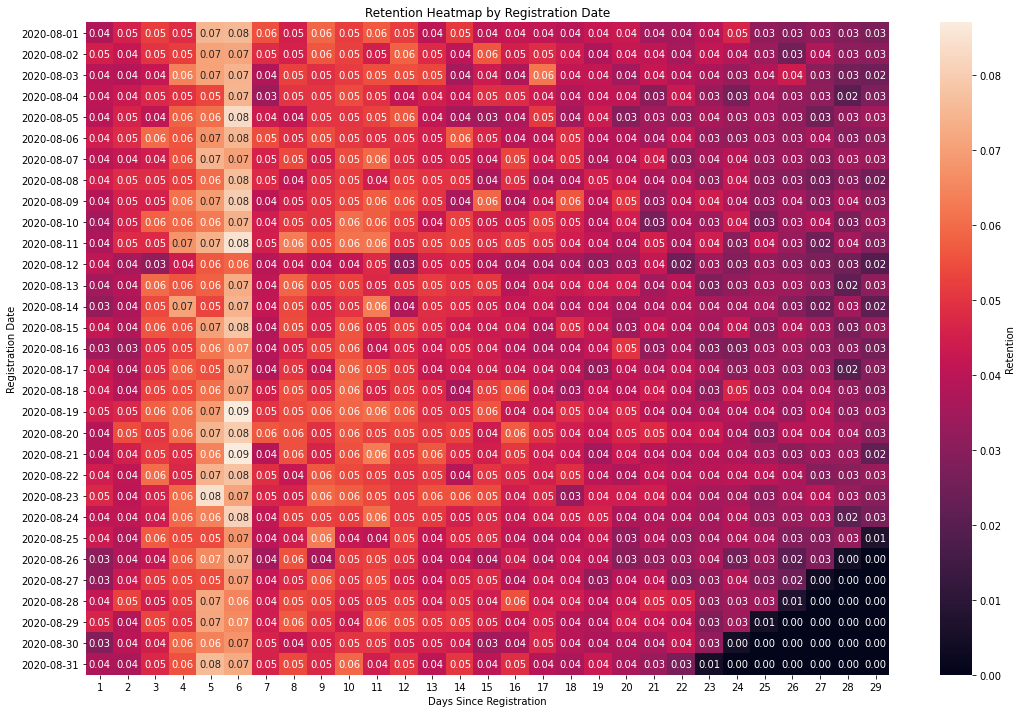

In [4]:
# Визуализация
if 0 in retention_matrix.columns:
    retention_matrix = retention_matrix.drop(columns=0)
plt.figure(figsize=(18, 12))
sns.heatmap(retention_matrix, annot=True, fmt=".2f", cmap="rocket", cbar_kws={'label': 'Retention'})
plt.title('Retention Heatmap by Registration Date')
plt.xlabel('Days Since Registration')
plt.ylabel('Registration Date')
plt.yticks(rotation=0)
plt.show()

**Вывод: была построена функция, считающая retemption и возвращающая матрицу с его значениями. Функция принимает на вход пути к данным, количество дней, по которым мы считаем retemption, и даты первой и последней исследуемых когорт**

*Задание 2
Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.*

*Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?*

In [5]:
df = pd.read_csv("Проект_1_Задание_2 (1).csv", sep=';',
    names=['user_id', 'revenue', 'testgroup'],
    dtype={'user_id': int, 'revenue': float, 'testgroup': str},
    skiprows=1)

   user_id  revenue testgroup
0        1      0.0         b
1        2      0.0         a
2        3      0.0         a
3        4      0.0         b
4        5      0.0         b
             user_id        revenue
count  404770.000000  404770.000000
mean   202385.500000      26.083435
std    116847.178567     681.652928
min         1.000000       0.000000
25%    101193.250000       0.000000
50%    202385.500000       0.000000
75%    303577.750000       0.000000
max    404770.000000   37433.000000
b    202667
a    202103
Name: testgroup, dtype: int64
Nulls: user_id      0
revenue      0
testgroup    0
dtype: int64
Duplicates: 0


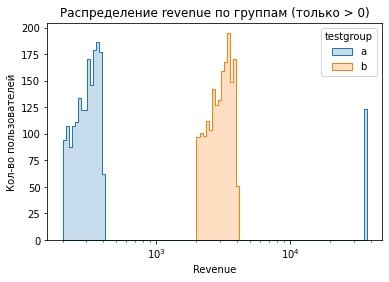

In [6]:
# EDA
print(df.head())
print(df.describe())
print(df['testgroup'].value_counts())
print("Nulls:", df.isna().sum())
print("Duplicates:", df.duplicated().sum())

# Убираем пользователей с нулевым revenue
df_nonzero = df[df['revenue'] > 0]

# Строим гистограмму распределения revenue по группам
sns.histplot(
    data=df_nonzero,
    x='revenue',
    hue='testgroup',
    bins=100,
    log_scale=(True, False),  # поможет визуализировать данные с большими разрывами
    element='step',
    stat='count',
    common_norm=False
)
plt.title("Распределение revenue по группам (только > 0)")
plt.xlabel("Revenue")
plt.ylabel("Кол-во пользователей")
plt.show()




Summary:
            users  payers    revenue        CR       ARPU
testgroup                                                
a          202103  1928.0  5136189.0  0.009540  25.413720
b          202667  1805.0  5421603.0  0.008906  26.751287

 T-test for ARPU: t = -0.623, p = 0.53296
Z-test for CR: z = 2.108, p = 0.03503
Bootstrap 95% CI for ARPU difference: -2.7451 to 5.5971


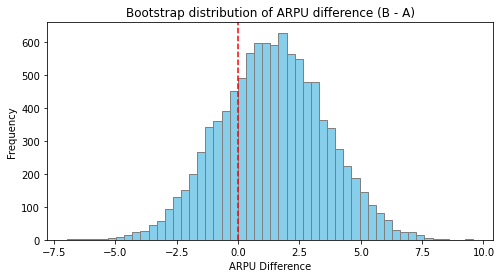

In [7]:
# Группировка по тестовой группе
grouped = df.groupby('testgroup')

# Расчёт ARPU, CR, ARPPU
summary = grouped.agg(
    users=('user_id', 'count'),
    payers=('revenue', lambda x: (x > 0).sum()),
    revenue=('revenue', 'sum')
)

summary['CR'] = summary['payers'] / summary['users']
summary['ARPU'] = summary['revenue'] / summary['users']

print("Summary:")
print(summary)

# --- Статистические тесты ---

# 1. ARPU t-test (на случай независимых выборок) (оставлю код, но лучше было бы ограничиться одним методом, и с учётом специфичных
# данных, всё-таки отдать предпочтение бутстрапу)
a = df[df['testgroup'] == 'a']['revenue']
b = df[df['testgroup'] == 'b']['revenue']

t_stat, p_val = ttest_ind(a, b, equal_var=False)
print(f"\n T-test for ARPU: t = {t_stat:.3f}, p = {p_val:.5f}")

# 2. Conversion Rate z-test(сравниватся доли, большое число наблюдений)
conversions = np.array([(a > 0).sum(), (b > 0).sum()])
totals = np.array([len(a), len(b)])

z_stat, p_z = proportions_ztest(conversions, totals)
print(f"Z-test for CR: z = {z_stat:.3f}, p = {p_z:.5f}")

# 3. Бутстрап ARPU(использование бутстрэпа обосновано большим количеством нулей и наличием очень крупных значений в контрольной группе.
#Заодно если распределение значимости средних похоже на нормальное, то это будет говорить о независимости данных согласно ЦПТ)
def bootstrap_metric(data1, data2, metric_func=np.mean, n_bootstrap=10000):
    diff_dist = []
    for _ in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=len(data1), replace=True)
        sample2 = np.random.choice(data2, size=len(data2), replace=True)
        diff = metric_func(sample2) - metric_func(sample1)
        diff_dist.append(diff)
    return np.percentile(diff_dist, [2.5, 97.5]), diff_dist

ci, distribution = bootstrap_metric(a.values, b.values)

print(f"Bootstrap 95% CI for ARPU difference: {ci[0]:.4f} to {ci[1]:.4f}")

# Визуализация распределения бутстрапа
plt.figure(figsize=(8, 4))
plt.hist(distribution, bins=50, color="skyblue", edgecolor="gray")
plt.axvline(0, color='red', linestyle='--')
plt.title("Bootstrap distribution of ARPU difference (B - A)")
plt.xlabel("ARPU Difference")
plt.ylabel("Frequency")
plt.show()

**ARPU вырос, но t-тест и бутстрап показывают, что разница неубедительна (CI охватывает 0, p = 0.53).**

**CR в тесте значимо хуже (p = 0.035).**

In [8]:
# Метрику ARPPU я решил не брать. Она не связана с конверсией и её изменения могут быть ложноположительным сигналом.
# Если новый набор предложений будет явно лучше, то такой вывод можно будет сделать и через ARPU.

**Какой можно сделать общий вывод? Новый набор предложений не даёт статистически значимого прироста для ключевых метрик, а конверсию понижает. Имеет смысл отказаться от нового набора предложений.**

In [9]:
# Возможно, имеет смысл поработать над ещё одним набором предложений, объеденив оба имеющихся набора. Было бы хорошо, если у нас
# и сохранятся "киты" и общая масса пользователей станет больше покупать. Нельзя сказать с уверенностью, что так случится, но это
# потенциальная идея для нового A/B теста

*Задание 3.
В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?*

*Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?*

Нам нужны метрики, которые отражали бы вовлечённость игроков, их прогресс и монетизацию.

Можно предложить подобные метрики:
**Event Participation Rate — доля активных игроков, которые начали событие.
Engaged Players — сколько игроков прошли хотя бы X уровней.
Completion Rate — доля игроков, прошедших событие полностью.
Avg Session Length — длительность игровых сессий.
Event ARPU / ARPPU — доход на пользователя/платящего в рамках события.
Event Conversion Rate — доля платящих среди участников события.**

Если мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад, нужно будет особое внимание уделять метрикам **Engaged Players, Completion Rate и Avg Session Length**. Если они будут падать, то это негативный сигнал. Особенно **Avg Session Length**. Если игроки стали меньше проводить время в игре, когда мы сделали усложнение - мы явно переборщили с механикой.

Также полезно было бы внести новые метрики(все старые тоже оставим):
**Levels Repeated — сколько раз игроки перепроходили один и тот же уровень.
Drop-off Points — на каких уровнях происходит массовый уход.
Avg Levels Rolled Back — насколько часто и сильно игроки откатываются.
Churn During Event — доля игроков, покинувших событие не дойдя до конца(имеет смысл и в обычном ивенте, но там она не настолько актуальна).**